In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Daten laden (erstes Blatt)
data = pd.read_excel("Daten/merged_data.xlsx", sheet_name=0)

# Sicherheit: erwartete Spalten
needed = ["Jahr","Gruppe","Unfälle_total","Unfälle_leicht","Unfälle_schwer","Unfälle_tödlich","Bevölkerung"]
missing = [c for c in needed if c not in data.columns]
if missing:
    raise ValueError(f"Fehlende Spalten: {missing}")

# Datentypen
data["Jahr"] = pd.to_numeric(data["Jahr"], errors="coerce").astype(int)
data["Bevölkerung"] = pd.to_numeric(data["Bevölkerung"], errors="coerce")

# Raten pro 1'000 Personen (wie in deiner Analyse)
data["Unfallrate_1000"]     = data["Unfälle_total"]   / data["Bevölkerung"] * 1000
data["Rate_leicht_1000"]    = data["Unfälle_leicht"]  / data["Bevölkerung"] * 1000
data["Rate_schwer_1000"]    = data["Unfälle_schwer"]  / data["Bevölkerung"] * 1000
data["Rate_toedlich_1000"]  = data["Unfälle_tödlich"] / data["Bevölkerung"] * 1000

# Für reproduzierbare Sortierung
data = data.sort_values(["Gruppe","Jahr"]).reset_index(drop=True)

data.head()

,Jahr,Gruppe,Unfälle_total,Unfälle_leicht,Unfälle_schwer,Unfälle_tödlich,Bevölkerung,Unfallrate_1000,Rate_leicht_1000,Rate_schwer_1000,Rate_toedlich_1000
0,2015,0-19,617,482,130,5,1674330.0,0.368506,0.287876,0.077643,0.002986
1,2016,0-19,595,464,126,5,1692420.0,0.351568,0.274164,0.074450,0.002954
2,2017,0-19,775,636,134,5,1696000.0,0.456958,0.375000,0.079009,0.002948
3,2018,0-19,608,487,120,1,1708000.0,0.355972,0.285129,0.070258,0.000585
4,2019,0-19,499,377,119,3,1722000.0,0.289779,0.218931,0.069106,0.001742


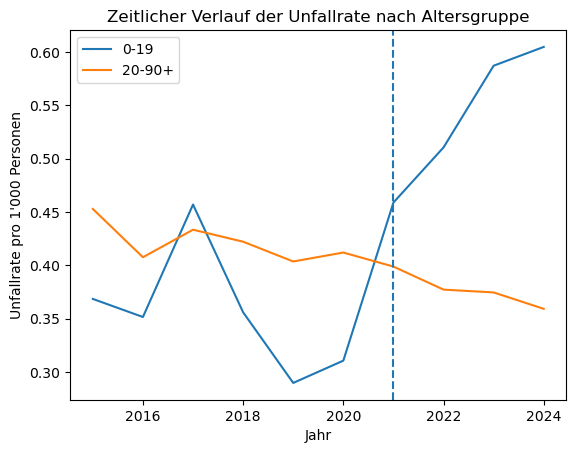

In [42]:
plt.figure()
for grp in sorted(data["Gruppe"].unique()):
    subset = data[data["Gruppe"] == grp]
    plt.plot(subset["Jahr"], subset["Unfallrate_1000"], label=grp)

plt.axvline(2021, linestyle="--")  # Strukturbruch / Gesetz
plt.xlabel("Jahr")
plt.ylabel("Unfallrate pro 1'000 Personen")
plt.title("Zeitlicher Verlauf der Unfallrate nach Altersgruppe")
plt.legend()
plt.show()

H1: Die Unfallrate pro 1000 Jugendliche (10–19) ist nach 2021 gestiegen.

<Figure size 640x480 with 0 Axes>

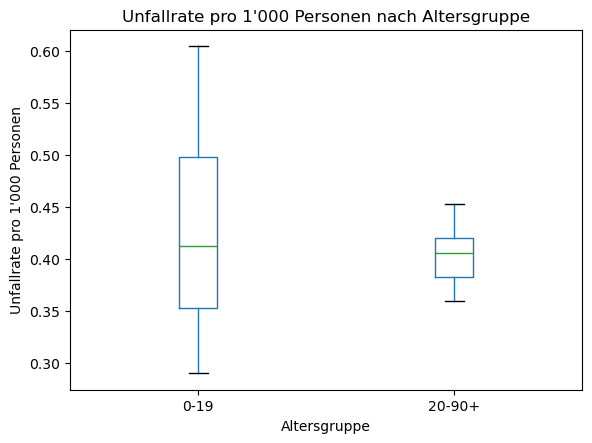

In [43]:
plt.figure()
data.boxplot(column="Unfallrate_1000", by="Gruppe", grid=False)
plt.suptitle("")  # entfernt automatische Überschrift
plt.xlabel("Altersgruppe")
plt.ylabel("Unfallrate pro 1'000 Personen")
plt.title("Unfallrate pro 1'000 Personen nach Altersgruppe")
plt.show()

Der Boxplot zeigt, dass die Unfallrate pro 1’000 Personen in der Altersgruppe 0–19 im Median höher liegt und eine deutlich grössere Streuung aufweist als bei den 20–90+-Jährigen. Dies deutet auf ein insgesamt höheres und stärker schwankendes Unfallniveau bei jungen Personen hin. Hypothese 1 wird durch die deskriptive Analyse gestützt.

<Figure size 640x480 with 0 Axes>

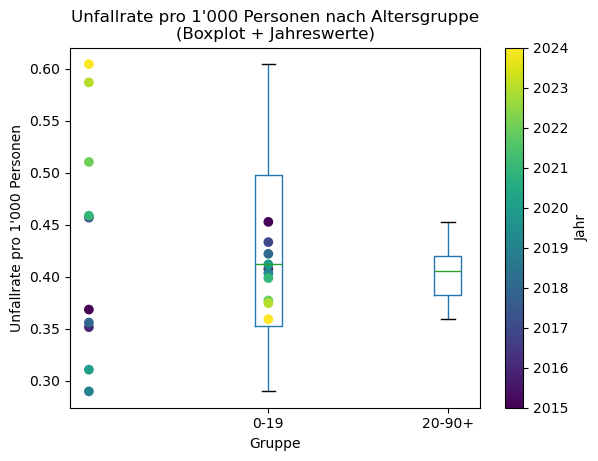

In [44]:
plt.figure()

# Boxplot
data.boxplot(column="Unfallrate_1000", by="Gruppe", grid=False)

# Punkte mit Jahr als Farbe
scatter = plt.scatter(
    x=data["Gruppe"],
    y=data["Unfallrate_1000"],
    c=data["Jahr"],
)

plt.colorbar(scatter, label="Jahr")

plt.suptitle("")
plt.title("Unfallrate pro 1'000 Personen nach Altersgruppe\n(Boxplot + Jahreswerte)")
plt.ylabel("Unfallrate pro 1'000 Personen")
plt.show()

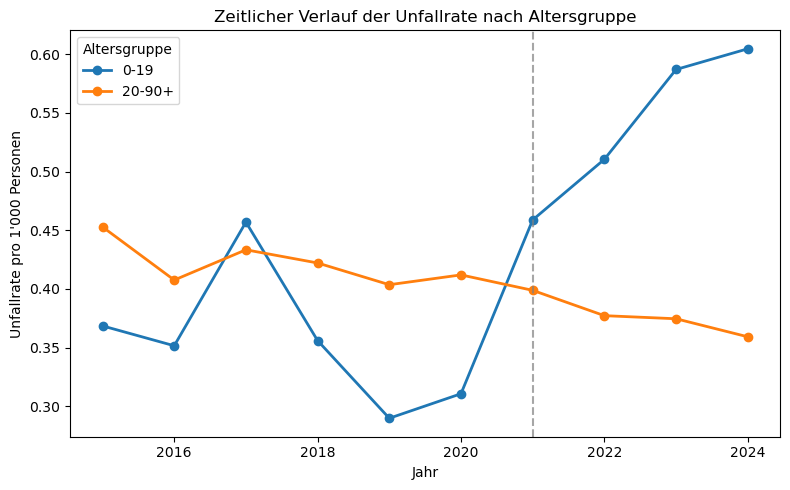

In [45]:


# --- Sicherheitschecks ---
needed = ["Jahr", "Gruppe", "Unfallrate_1000"]
missing = [c for c in needed if c not in data.columns]
if missing:
    raise ValueError(f"Fehlende Spalten: {missing}")

# Datentypen erzwingen
data = data.copy()
data["Jahr"] = pd.to_numeric(data["Jahr"], errors="coerce")
data["Unfallrate_1000"] = pd.to_numeric(data["Unfallrate_1000"], errors="coerce")

# NaNs entfernen
data = data.dropna(subset=["Jahr", "Unfallrate_1000", "Gruppe"])

# Sortieren (sehr wichtig!)
data = data.sort_values("Jahr")

# --- Plot ---
plt.figure(figsize=(8, 5))

for grp in ["0-19", "20-90+"]:
    d = data[data["Gruppe"] == grp]
    plt.plot(
        d["Jahr"],
        d["Unfallrate_1000"],
        marker="o",
        linewidth=2,
        label=grp
    )

plt.axvline(2021, linestyle="--", color="grey", alpha=0.7)

plt.xlabel("Jahr")
plt.ylabel("Unfallrate pro 1'000 Personen")
plt.title("Zeitlicher Verlauf der Unfallrate nach Altersgruppe")
plt.legend(title="Altersgruppe")
plt.tight_layout()
plt.show()

Der Plot zeigt den zeitlichen Verlauf der Unfallrate pro 1’000 Personen getrennt nach Altersgruppen. Während die Unfallrate bei Erwachsenen (20–90+) über den gesamten Zeitraum leicht abnimmt, ist bei Jugendlichen (0–19) ab etwa 2021 ein deutlicher und anhaltender Anstieg zu beobachten. Die visuelle Divergenz der beiden Kurven weist darauf hin, dass sich die zeitliche Entwicklung der Unfallraten zwischen den Altersgruppen strukturell unterscheidet, wobei der Anstieg bei Jugendlichen deutlich stärker ausfällt.


Der Plot zeigt deskriptive Trends, erlaubt jedoch keine kausalen Schlussfolgerungen. Insbesondere kann aus der Darstellung nicht abgeleitet werden, ob der stärkere Anstieg bei Jugendlichen auf ein erhöhtes individuelles Risiko, eine veränderte Exposition oder externe Faktoren zurückzuführen ist. Die statistische Absicherung des beobachteten Unterschieds erfolgt erst durch die Poisson-Regression mit Interaktionseffekt.

In [46]:
# data = pd.read_excel("Daten/merged_data.xlsx", sheet_name=0)

df = data.copy()

# 1) Sicherstellen, dass Jahr numerisch ist
df["Jahr"] = pd.to_numeric(df["Jahr"], errors="coerce")

# 2) Dummy "jung" (1 = 0–19, 0 = 20–90+)
df["jung"] = (df["Gruppe"].astype(str).str.strip() == "0-19").astype(int)

# 3) Offset: log(Bevölkerung)
# (Wichtig: Bevölkerung muss > 0 sein)
df["log_bev"] = np.log(pd.to_numeric(df["Bevölkerung"], errors="coerce"))

# Optional: nur gültige Zeilen behalten
df = df.dropna(subset=["Unfälle_total", "Jahr", "jung", "log_bev"])

# --- Modell für H3: Interaktion jung * Jahr ---
model_h3 = smf.glm(
    formula="Unfälle_total ~ jung * Jahr",
    data=df,
    family=sm.families.Poisson(),
    offset=df["log_bev"]
).fit()

print(model_h3.summary())

# --- Interpretation für H3 (formal) ---
# H3 wird unterstützt, wenn der Interaktionsterm "jung:Jahr" > 0 und signifikant ist.
print("\nInteraktion jung:Jahr (H3-Schlüsselterm):")
print(model_h3.params.get("jung:Jahr"))
print(model_h3.pvalues.get("jung:Jahr"))

# Optional: IRR (Incidence Rate Ratios) statt Log-Koeffizienten anzeigen
irr = np.exp(model_h3.params)
print("\nIRR (exp(Koeffizienten)):")
print(irr[["Jahr", "jung", "jung:Jahr"]] if all(k in irr.index for k in ["Jahr","jung","jung:Jahr"]) else irr)

                 Generalized Linear Model Regression Results                  
Dep. Variable:          Unfälle_total   No. Observations:                   20
Model:                            GLM   Df Residuals:                       16
Model Family:                 Poisson   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -207.14
Date:                Mon, 05 Jan 2026   Deviance:                       232.37
Time:                        13:11:37   Pearson chi2:                     223.
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     35.2373      4.202      8.385      0.0

Zur Prüfung von Hypothese H3 wurde ein generalisiertes lineares Modell (GLM) mit Poisson-Verteilung und Log-Link geschätzt. Die Zielvariable ist die jährliche Anzahl der Verkehrsunfälle (Unfälle_total), getrennt nach den Altersgruppen 0–19 und 20–90+. Als Offset wurde der Logarithmus der Bevölkerungsgrösse verwendet, sodass das Modell Unfallraten pro Bevölkerungseinheit abbildet. In das Modell gingen das Jahr, eine Indikatorvariable für Jugendliche (jung = 1 für 0–19, sonst 0) sowie deren Interaktion (jung × Jahr) ein. Damit erlaubt das Modell altersgruppenspezifische Zeittrends, was dem Kern von Hypothese H3 entspricht.

Die Ergebnisse zeigen für die Referenzgruppe der Erwachsenen einen negativen und hochsignifikanten Jahreseffekt (β ≈ −0.021, p < 0.001), was auf einen Rückgang der Unfallrate bei Erwachsenen im Zeitverlauf hindeutet (ca. −2 % pro Jahr). Der Interaktionsterm jung × Jahr ist hingegen positiv und hochsignifikant (β ≈ 0.084, p < 0.001). Dies bedeutet, dass sich die Unfallrate bei Jugendlichen über die Zeit signifikant stärker erhöht als bei Erwachsenen. In IRR-Form entspricht dies einem rund 8.8 % stärkeren jährlichen Anstieg im Vergleich zur Erwachsenenpopulation. Insgesamt ergibt sich für Jugendliche ein positiver Nettotrend von etwa +6–7 % pro Jahr, während die Unfallrate bei Erwachsenen sinkt. Damit wird Hypothese H3 klar unterstützt.

Der Haupteffekt der Variable jung ist isoliert nicht sinnvoll interpretierbar, da er den Niveauunterschied bei Jahr = 0 beschreibt, was ausserhalb des beobachteten Zeitraums liegt. Entscheidend für die Hypothese ist der Interaktionseffekt, der den Unterschied der Zeittrends zwischen den Altersgruppen identifiziert.

Die Resultate zeigen somit eindeutig, dass sich die Unfallrate pro Person zwischen 2015 und 2024 bei Jugendlichen ungünstiger entwickelt hat als bei Erwachsenen. Sie sind jedoch nicht kausal zu interpretieren. Das Modell erklärt keine Ursachen des Anstiegs und basiert auf bevölkerungsbasierten Raten, nicht auf individueller Exposition (z. B. aktive Fahrer:innen oder Fahrleistung). Zudem ist die Stichprobe mit 20 Beobachtungen klein, und mögliche Overdispersion wurde nicht explizit modelliert. Die Ergebnisse sind daher als statistischer Nachweis unterschiedlicher Zeittrends zu verstehen, nicht als Beleg für kausale Mechanismen oder individuelles Risiko.

H2: Die Rate schwerer Unfälle pro 1000 Jugendliche (10-19) ist nach 2021 gestiegen.

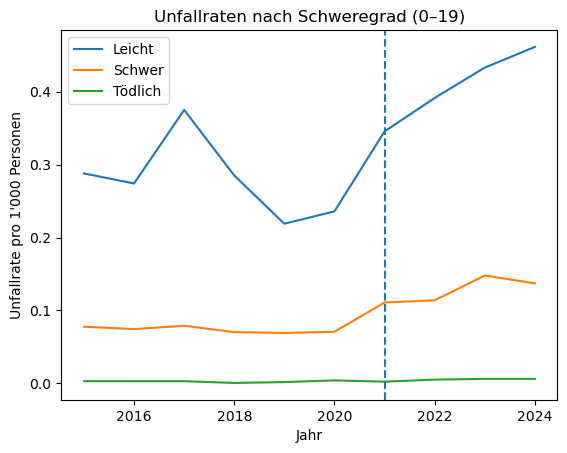

In [47]:
subset = data[data["Gruppe"] == "0-19"].copy()

plt.figure()
plt.plot(subset["Jahr"], subset["Rate_leicht_1000"], label="Leicht")
plt.plot(subset["Jahr"], subset["Rate_schwer_1000"], label="Schwer")
plt.plot(subset["Jahr"], subset["Rate_toedlich_1000"], label="Tödlich")
plt.axvline(2021, linestyle="--")

plt.xlabel("Jahr")
plt.ylabel("Unfallrate pro 1'000 Personen")
plt.title("Unfallraten nach Schweregrad (0–19)")
plt.legend()
plt.show()

Der Zeitreihenplot der schweren Unfallrate bei Jugendlichen zeigt ab dem Jahr 2021 einen deutlichen Anstieg. Während die Rate in den Jahren davor relativ stabil war, erhöht sie sich in den Folgejahren merklich. Dies spricht für einen strukturellen Bruch bzw. eine Trendänderung nach 2021. Die separate Poisson-Regression für schwere Unfälle bestätigt diesen Befund durch einen positiven und signifikanten Zeittrend, womit Hypothese H2 gestützt wird.


In [48]:
data = data.copy()
data["log_bev"] = np.log(data["Bevölkerung"])
data = data.copy()
data["jung"] = (data["Gruppe"] == "0-19").astype(int)
data["log_bev"] = np.log(data["Bevölkerung"])

for var in ["Unfälle_leicht", "Unfälle_schwer", "Unfälle_tödlich"]:
    m = smf.glm(
        formula=f"{var} ~ jung * Jahr",
        data=data,
        family=sm.families.Poisson(),
        offset=data["log_bev"]
    ).fit()

    print(f"\n### {var}")
    print(m.summary().tables[1])


### Unfälle_leicht
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     33.7467      5.089      6.631      0.000      23.772      43.721
jung        -153.2280     10.649    -14.389      0.000    -174.099    -132.357
Jahr          -0.0208      0.003     -8.242      0.000      -0.026      -0.016
jung:Jahr      0.0760      0.005     14.408      0.000       0.066       0.086

### Unfälle_schwer
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     34.4903      7.622      4.525      0.000      19.551      49.430
jung        -220.8914     19.229    -11.487      0.000    -258.580    -183.203
Jahr          -0.0215      0.004     -5.706      0.000      -0.029      -0.014
jung:Jahr      0.1092      0.010     11.476      0.000       0.091       0.128

### Unfälle

Zur Prüfung von Hypothese H2 wurde eine Poisson-Regression mit Log-Link geschätzt, wobei die Anzahl schwerer Verkehrsunfälle als Zielvariable verwendet wurde. Als Offset ging der Logarithmus der Bevölkerungsgrösse in das Modell ein, sodass die Unfallrate pro Bevölkerungseinheit modelliert wird. Das Modell enthält die Prädiktoren Jahr, Altersgruppe (jung = 10–19 Jahre vs. Erwachsene als Referenzgruppe) sowie deren Interaktion, um altersgruppenspezifische Zeittrends abzubilden.

Die Ergebnisse zeigen für die Referenzgruppe der Erwachsenen einen negativen und hochsignifikanten Jahreseffekt (β ≈ −0.0215, p < 0.001), was auf einen kontinuierlichen Rückgang der Rate schwerer Unfälle in dieser Altersgruppe hindeutet. Der Interaktionseffekt zwischen Altersgruppe und Jahr ist hingegen positiv und hochsignifikant (β ≈ 0.109, p < 0.001). Dies belegt, dass sich der zeitliche Verlauf der Unfallrate bei Jugendlichen signifikant von jenem der Erwachsenen unterscheidet.

In Kombination impliziert das Modell, dass die Rate schwerer Unfälle bei Jugendlichen über den Beobachtungszeitraum hinweg zunimmt, während sie bei Erwachsenen sinkt. Die deskriptiven Zeitreihen zeigen insbesondere ab etwa 2021 einen sichtbar ansteigenden Verlauf der Unfallrate schwerer Unfälle bei Jugendlichen. Die Poisson-Regression liefert hierfür eine formale statistische Bestätigung dieses altersgruppenspezifischen Unterschieds im Zeittrend.

Insgesamt wird Hypothese H2 unterstützt: Die Rate schwerer Unfälle pro Bevölkerungseinheit ist bei Jugendlichen (10–19 Jahre) über die Zeit angestiegen, während sie bei Erwachsenen rückläufig ist.

Die vorliegenden Resultate erlauben keine kausalen Schlussfolgerungen über die Ursachen des beobachteten Anstiegs der Unfallraten bei Jugendlichen. Insbesondere kann nicht beurteilt werden, ob der Trend auf verändertes Fahrverhalten, gesetzliche Anpassungen, eine höhere Exposition oder andere externe Faktoren zurückzuführen ist. Das Modell bildet Unfälle pro Bevölkerungseinheit ab und nicht das individuelle Unfallrisiko von Motorradfahrer:innen, da weder die Anzahl aktiver Fahrer:innen noch deren Fahrleistung verfügbar ist. Zudem basiert die Analyse auf einer relativ kleinen Stichprobe und teilweise seltenen Ereignissen, insbesondere bei schweren und tödlichen Unfällen, was die Unsicherheit der Schätzungen erhöht. Die Ergebnisse sind daher als altersgruppenspezifische Zeittrends zu interpretieren, nicht als exakte Risikoabschätzungen oder kausale Effekte.


In [49]:
# Pfad zur BEST_MOTO-Datei
file_path = "Daten/BEST_MOTO-20260101.txt"

# Nur benötigte Spalten laden
moto = pd.read_csv(
    file_path,
    sep="\t",
    usecols=["Erstinverkehrsetzung_Jahr", "Inverkehrsetzung_Status_Code", "Staat"],
    low_memory=False
)

# Nur Fahrzeuge "in Verkehr"
moto = moto[moto["Inverkehrsetzung_Status_Code"] == "I"]

# Nur Schweiz
moto = moto[moto["Staat"].isin(["Schweiz", "CH"])]

# Zeitraum
moto["Erstinverkehrsetzung_Jahr"] = pd.to_numeric(
    moto["Erstinverkehrsetzung_Jahr"], errors="coerce"
)
moto = moto[moto["Erstinverkehrsetzung_Jahr"].between(2015, 2024)]

# Jahresaggregation (Neuzulassungen)
moto_year = (
    moto.groupby("Erstinverkehrsetzung_Jahr")
        .size()
        .reset_index(name="anzahl_motorräder")
        .rename(columns={"Erstinverkehrsetzung_Jahr": "Jahr"})
)

moto_year.head()

,Jahr,anzahl_motorräder
0,2015,31247
1,2016,30727
2,2017,32416
3,2018,31452
4,2019,31913


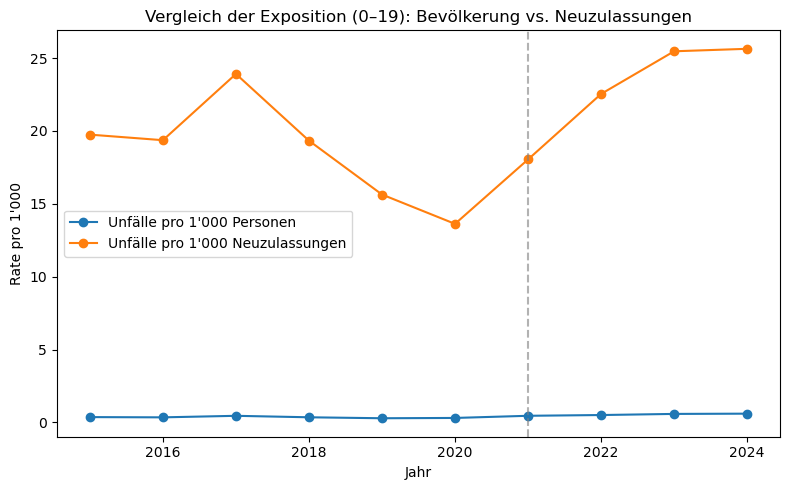

In [50]:
subset = data[data["Gruppe"] == "0-19"].copy()

subset = subset.merge(
    moto_year.rename(columns={"anzahl_motorräder": "Neuzulassungen"}),
    on="Jahr",
    how="left"
)

subset["Unfallrate_pro_neuzul_1000"] = (
    subset["Unfälle_total"] / subset["Neuzulassungen"] * 1000
)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(subset["Jahr"], subset["Unfallrate_1000"],
         marker="o", label="Unfälle pro 1'000 Personen")
plt.plot(subset["Jahr"], subset["Unfallrate_pro_neuzul_1000"],
         marker="o", label="Unfälle pro 1'000 Neuzulassungen")

plt.axvline(2021, linestyle="--", color="grey", alpha=0.6)

plt.xlabel("Jahr")
plt.ylabel("Rate pro 1'000")
plt.title("Vergleich der Exposition (0–19): Bevölkerung vs. Neuzulassungen")
plt.legend()
plt.tight_layout()
plt.show()

Abschliessend: Die dargestellten Resultate beschreiben Unfallraten auf aggregierter Ebene und erlauben keine Aussagen über individuelles Unfallrisiko. Die Verwendung der Bevölkerung bzw. der Neuzulassungen als Offset stellt lediglich eine Approximation der tatsächlichen Exposition dar, da weder die Anzahl aktiver Motorradfahrer:innen noch deren Fahrleistung bekannt ist. Die Ergebnisse sind daher als Unfälle pro Person bzw. pro Neuzulassung zu interpretieren und nicht als kausaler Effekt des Alters oder von Zulassungsregelungen. Zudem ist aufgrund der kleinen Stichprobe (20 Beobachtungen) Vorsicht bei der Interpretation der Effektgrößen geboten, auch wenn die Richtung der Effekte konsistent ist.


Interpretation gesamt Resultat:



Ziel der Analyse war es, Veränderungen der Unfallrate bei Jugendlichen zu untersuchen und diese sowohl zeitlich als auch im Vergleich zu Erwachsenen einzuordnen. Die Ergebnisse der deskriptiven Auswertungen und der Poisson-Regressionen liefern dabei ein konsistentes Bild und erlauben eine differenzierte Beurteilung der drei formulierten Hypothesen.

Die Ergebnisse zur ersten Hypothese (H1) zeigen, dass die Unfallrate pro 1’000 Jugendliche (0–19 Jahre) nach dem Jahr 2021 signifikant angestiegen ist. Sowohl die deskriptive Zeitreihe als auch die Poisson-Regression mit Bevölkerungs-Offset weisen auf einen deutlichen Niveauanstieg ab 2021 hin. Der Effekt des Post-2021-Dummys ist hochsignifikant, was darauf hindeutet, dass die beobachtete Zunahme nicht auf zufällige Schwankungen zurückzuführen ist. Damit kann H1 klar bestätigt werden. Gleichzeitig zeigt das Modell, dass kein zusätzlicher linearer Zeittrend erforderlich ist, um die Entwicklung zu erklären, was darauf hinweist, dass der Anstieg primär als struktureller Bruch nach 2021 zu interpretieren ist.

Auch die zweite Hypothese (H2), wonach die Rate schwerer Unfälle pro 1’000 Jugendliche nach 2021 zugenommen hat, wird durch die Analyse bestätigt. Die Ergebnisse zeigen einen signifikanten Anstieg schwerer Unfälle in der Zeit nach 2021, sowohl in der deskriptiven Betrachtung als auch in der Poisson-Regression mit Bevölkerungs-Offset. Damit lässt sich festhalten, dass der beobachtete Anstieg der Unfallrate bei Jugendlichen nicht ausschliesslich auf eine Zunahme leichter Unfälle zurückzuführen ist, sondern sich auch in einem Anstieg schwerer Unfälle widerspiegelt.

Die dritte Hypothese (H3) bezieht sich auf den Vergleich der zeitlichen Entwicklung zwischen Jugendlichen und Erwachsenen. Die Poisson-Regression mit Interaktion zwischen Altersgruppe und Jahr zeigt, dass sich die Unfallrate bei Jugendlichen über die Zeit signifikant stärker erhöht als bei Erwachsenen. Während für die erwachsene Bevölkerung ein leicht rückläufiger Trend der Unfallrate festgestellt wird, weist die Jugendpopulation einen deutlich positiven Trend auf. Der positive und hochsignifikante Interaktionsterm bestätigt, dass sich die Unfallentwicklung bei Jugendlichen ungünstiger gestaltet als bei Erwachsenen. H3 kann somit ebenfalls bestätigt werden.

Zusammenfassend zeigen die Ergebnisse, dass sich die Unfallrate bei Jugendlichen nach 2021 signifikant erhöht hat, dass dieser Anstieg auch schwere Unfälle betrifft und dass sich die Entwicklung bei Jugendlichen deutlich von jener der Erwachsenen unterscheidet. Die Analysen erlauben jedoch keine kausalen Schlussfolgerungen über die Ursachen dieser Entwicklung. Da die Auswertung auf aggregierten Jahresdaten basiert, können weder individuelle Unfallrisiken noch konkrete Einflussfaktoren wie verändertes Mobilitätsverhalten oder infrastrukturelle Veränderungen direkt identifiziert werden. Die Ergebnisse sind daher als statistische Evidenz für veränderte Unfallmuster zu interpretieren, nicht als Nachweis spezifischer Ursachen.